/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 14 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 01 2009 Kepler    1800 kplr010619192      0.0
  1 Kepler Quarter 02 2009 Kepler    1800 kplr010619192      0.0
  2 Kepler Quarter 03 2009 Kepler    1800 kplr010619192      0.0
  3 Kepler Quarter 04 2010 Kepler    1800 kplr010619192      0.0
  4 Kepler Quarter 05 2010 Kepler    1800 kplr010619192      0.0
  5 Kepler Quarter 06 2010 Kepler    1800 kplr010619192      0.0
  6 Kepler Quarter 08 2011 Kepler    1800 kplr010619192      0.0
  7 Kepler Quarter 09 2011 Kepler    1800 kplr010619192      0.0
  8 Kepler Quarter 10 2011 Kepler    1800 kplr010619192      0.0
  9 Kepler Quarter 12 2012 Kepler    1800 kplr010619192      0.0
 10 Kepler Quarter 13 2012 Kepler    1800 kplr010619192      0.0
 11 Kepler Quarter 14 2012 Kepler    1800 kplr0

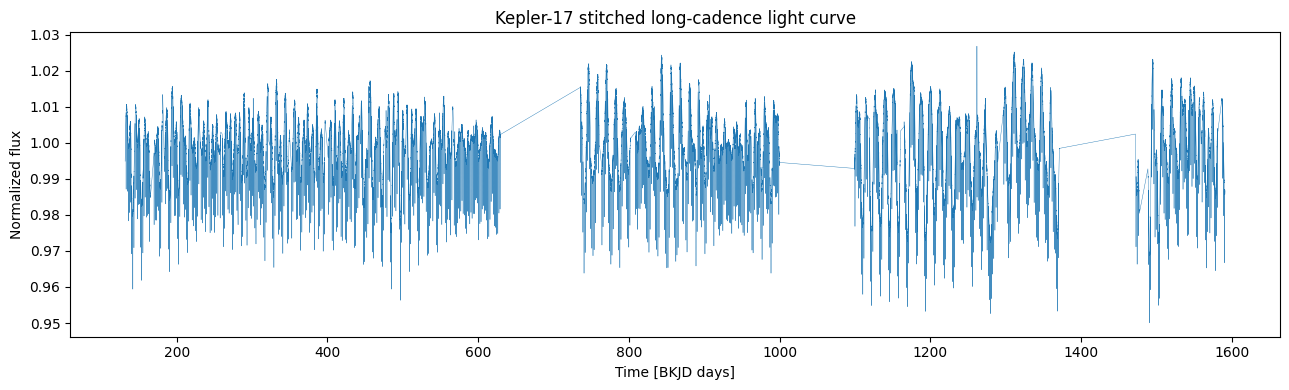

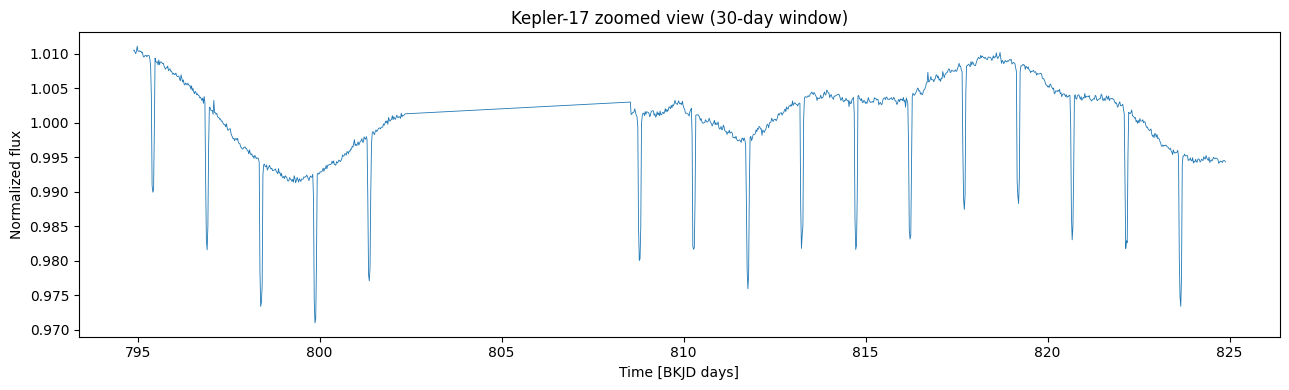

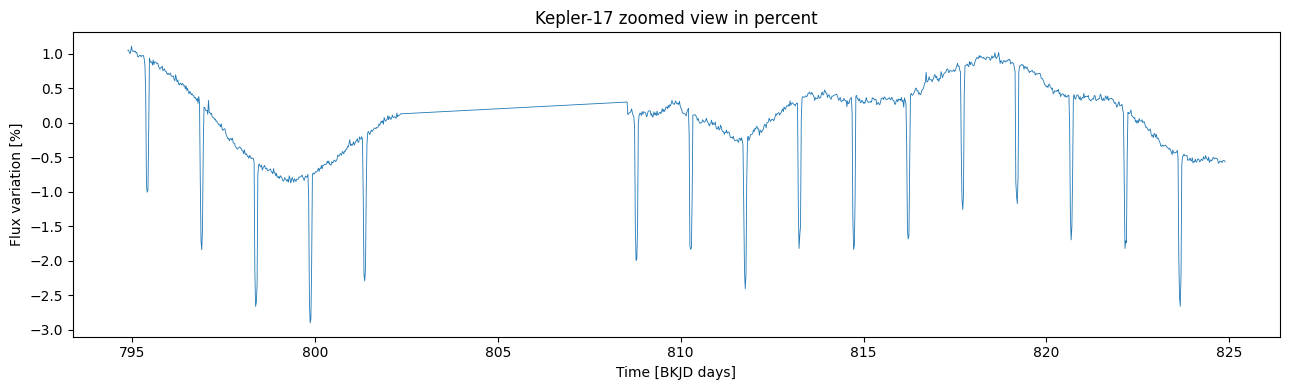

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

# -----------------------------
# 1) Search for Kepler-17 data
# -----------------------------
target = "Kepler-17"

sr = lk.search_lightcurve(
    target,
    mission="Kepler",
    author="Kepler",
    exptime=1800,   # long cadence (~29.4 min)
)

print(sr)
print(f"\nFound {len(sr)} long-cadence products.")

# -----------------------------
# 2) Download and stitch
# -----------------------------
lcc = sr.download_all()

# Normalize each quarter before stitching to reduce quarter-to-quarter jumps
lc = lcc.stitch(corrector_func=lambda x: x.normalize())

# Basic cleanup
lc = lc.remove_nans().remove_outliers()

print(lc)
print("Number of stitched points:", len(lc.time))

# -----------------------------
# 3) Extract arrays
# -----------------------------
t = lc.time.value
y = lc.flux.value
first_600 = t<600
# t = t[first_600]
# y = y[first_600]

# -----------------------------
# 4) Full-mission plot
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, y, lw=0.3)
ax.set_title("Kepler-17 stitched long-cadence light curve")
ax.set_xlabel("Time [BKJD days]")
ax.set_ylabel("Normalized flux")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Zoomed-in plot
# -----------------------------
# pick a 30-day window near the middle
t0 = np.nanmedian(t)
mask = (t > t0 - 15) & (t < t0 + 15)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t[mask], y[mask], lw=0.6)
ax.set_title("Kepler-17 zoomed view (30-day window)")
ax.set_xlabel("Time [BKJD days]")
ax.set_ylabel("Normalized flux")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Optional: plot in percent deviation from median
# -----------------------------
y_pct = 100 * (y / np.nanmedian(y) - 1)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t[mask], y_pct[mask], lw=0.6)
ax.set_title("Kepler-17 zoomed view in percent")
ax.set_xlabel("Time [BKJD days]")
ax.set_ylabel("Flux variation [%]")
plt.tight_layout()
plt.show()

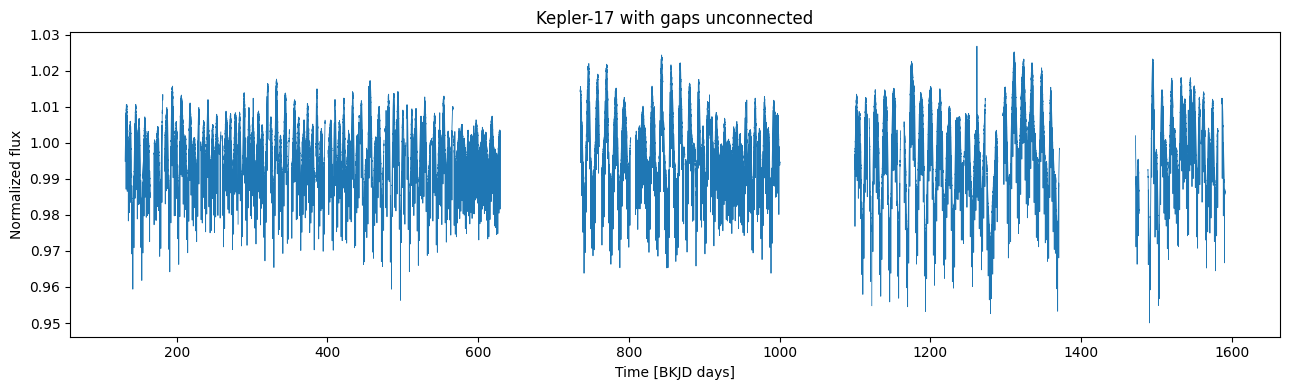

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# t = lc.time.value
# y = lc.flux.value.copy()

# break lines across large gaps
dt = np.diff(t)
gap_thresh = 0.5   # days; adjust as needed
break_idx = np.where(dt > gap_thresh)[0]

y_plot = y.copy()
for i in break_idx:
    y_plot[i + 1] = np.nan   # NaN breaks the plotted line

plt.figure(figsize=(13,4))
plt.plot(t, y_plot, lw=0.6)
plt.xlabel("Time [BKJD days]")
plt.ylabel("Normalized flux")
plt.title("Kepler-17 with gaps unconnected")
plt.tight_layout()
plt.show()

In [3]:
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND

# Convert to torch tensors
x = torch.tensor(t, dtype=torch.float64).unsqueeze(-1)  # (N, 1)
y_flux = torch.tensor(y, dtype=torch.float64)

# Normalize x to [0, 1] and standardize y
x_min, x_max = x.min(), x.max()
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y_flux.mean(), y_flux.std()
y_flux = (y_flux - y_mean) / y_std

print(f"N = {x.shape[0]}")
print(f"x range: {x.min().item():.4f} to {x.max().item():.4f}")
print(f"y mean={y_flux.mean():.4f}, std={y_flux.std():.4f}")

N = 51733
x range: 0.0000 to 1.0000
y mean=-0.0000, std=1.0000


In [6]:
EPSILON = 1e-4
kernel_type = 'SquaredExponential'
cg_tol = 1e-6
noise_floor = 1e-1 

In [9]:
max_iters =200
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
}

model = EFGPND(x, y_flux, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.3)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol,noise_floor=noise_floor)
    optimizer.step()

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)

    if it % 10 == 0:
        print(f"iter {it:>3}  ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}")

print(f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}")

iter   0  ℓ=0.108  σ_f²=1.35  σ_n²=0.27
iter  10  ℓ=0.011  σ_f²=11.4  σ_n²=1.771
iter  20  ℓ=0.001738  σ_f²=48.06  σ_n²=1.32
iter  30  ℓ=0.001256  σ_f²=11.87  σ_n²=0.2904
iter  40  ℓ=0.001206  σ_f²=1.784  σ_n²=0.1069
iter  50  ℓ=0.001041  σ_f²=0.4533  σ_n²=0.1834
iter  60  ℓ=0.001141  σ_f²=0.7761  σ_n²=0.2132
iter  70  ℓ=0.001291  σ_f²=1.228  σ_n²=0.1626
iter  80  ℓ=0.001174  σ_f²=1.05  σ_n²=0.1706


KeyboardInterrupt: 

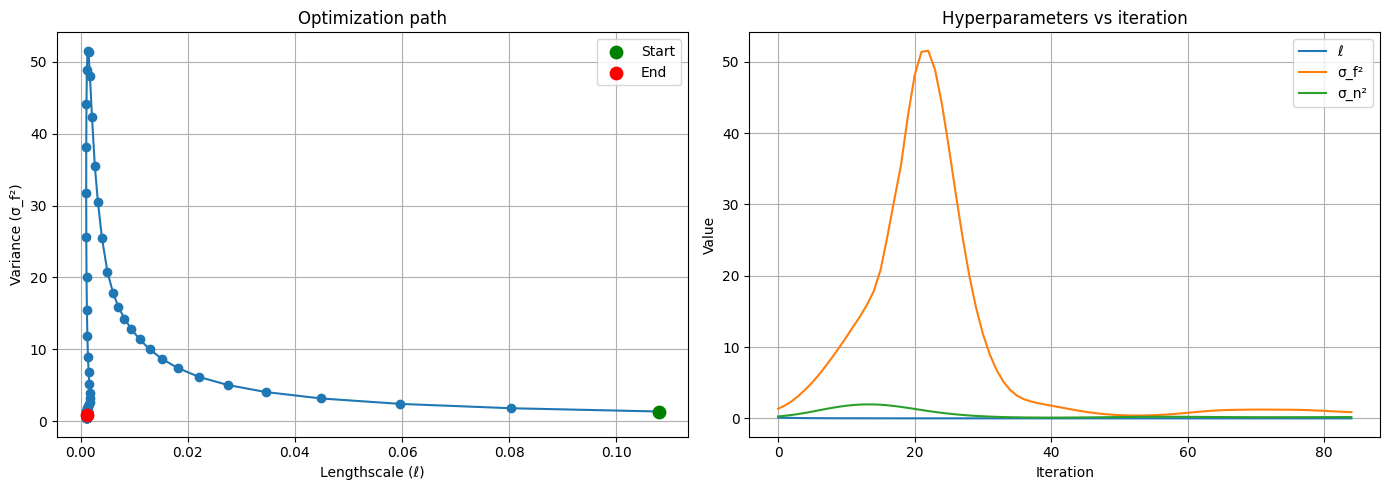

In [10]:
# Plot optimization convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ℓ)')
ax1.set_ylabel('Variance (σ_f²)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ℓ')
ax2.plot(training_log['iter'], training_log['variance'], label='σ_f²')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='σ_n²')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [11]:
# Predict posterior mean
x_pred = torch.linspace(0, 1, 5000, dtype=x.dtype).unsqueeze(-1)
mean_pred = model.predict(x_new=x_pred, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

# Inverse transform
t_pred = (x_pred.squeeze().numpy() * (x_max - x_min).item() + x_min.item())
flux_pred = (mean_pred.detach().cpu().numpy() * y_std.item() + y_mean.item())

# Also inverse transform the training data for plotting
t_orig = (x.squeeze().numpy() * (x_max - x_min).item() + x_min.item())
y_orig = (y_flux.numpy() * y_std.item() + y_mean.item())

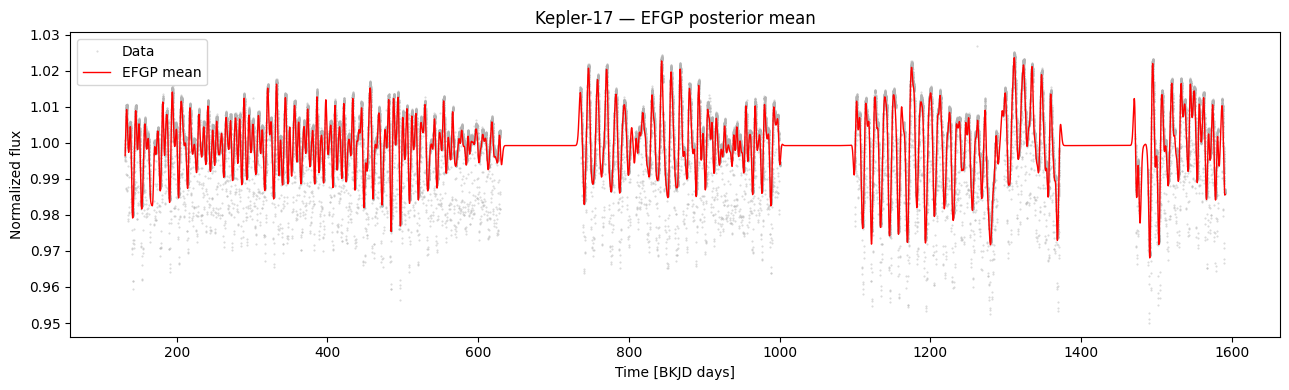

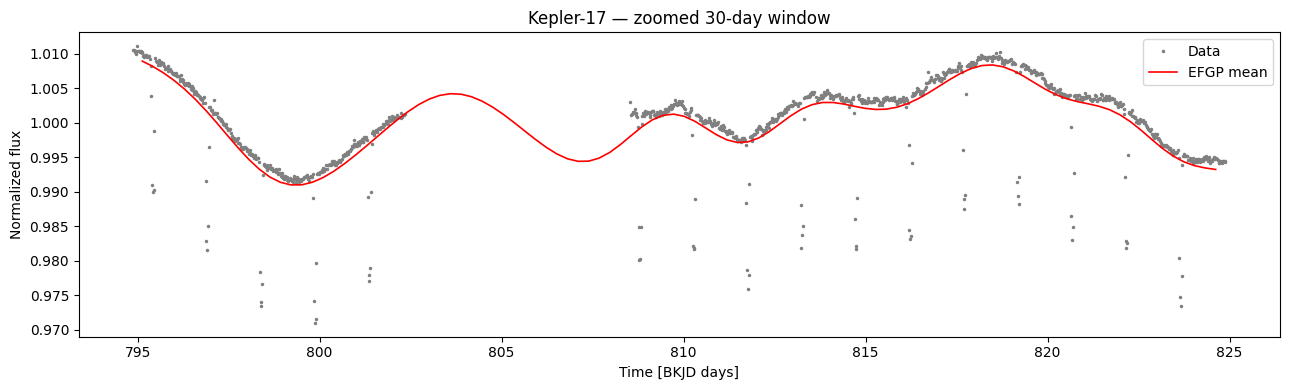

In [12]:
# Full light curve with GP fit
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_orig, y_orig, '.', color='0.7', markersize=1, alpha=0.5, label='Data')
ax.plot(t_pred, flux_pred, 'r-', lw=1, label='EFGP mean')
ax.set_xlabel('Time [BKJD days]')
ax.set_ylabel('Normalized flux')
ax.set_title('Kepler-17 — EFGP posterior mean')
ax.legend()
plt.tight_layout()

# Zoomed view (30-day window near the middle)
t_mid = np.nanmedian(t_orig)
fig, ax = plt.subplots(figsize=(13, 4))
mask_d = (t_orig > t_mid - 15) & (t_orig < t_mid + 15)
mask_p = (t_pred > t_mid - 15) & (t_pred < t_mid + 15)
ax.plot(t_orig[mask_d], y_orig[mask_d], '.', color='0.5', markersize=3, label='Data')
ax.plot(t_pred[mask_p], flux_pred[mask_p], 'r-', lw=1.2, label='EFGP mean')
ax.set_xlabel('Time [BKJD days]')
ax.set_ylabel('Normalized flux')
ax.set_title('Kepler-17 — zoomed 30-day window')
ax.legend()
plt.tight_layout()